In [1]:
import sys
sys.path.append("../feature_extraction")
import os
import glob
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic, binned_statistic_2d
import catalog_extraction_library as celib 
import query_library as qlib
import utility
from astropy.table import Table
from astropy.stats import sigma_clipped_stats
from astropy.coordinates import SkyCoord 
from astropy import units as u


In [2]:
features = utility.get_features_table(path ="/data1/isaccheo/standard_features/2025-11-11" ) 
print("Features loaded")
coadd = qlib.query_coadd_photometry(keep_cmodel = False, keep_extendedness = True)
print("coadd loaded")
truth = qlib.query_truth_table(columns = "all")

Features loaded
coadd loaded


In [3]:
band = "r"
table = coadd.merge(features, on = "objectId", how = "left")
table = table.merge(truth, on = "objectId", how = "inner")
print(len(features), len(truth), len(coadd), len(table))
table = table[utility.keep_non_flagged(table, band = band)]
print(len(table))
df = table[utility.keep_non_edges(table, mag_min= 26)]
print(len(df))
df = df[~utility.mask_nearby_stars(df, band = band, star_mag = [9, 11.5], sep_radius = [2,1])]
print(len(df))

366332 290760 367259 290760
68006
63421
61757


In [4]:
Nsigma = 3
clipping_sigma = 10 
delta_mag_bin = 0.1
std_min = 0.001
mag_lim = 16
interpolate = True
df["label"] = utility.get_truth_label(df)
bins = np.hstack([np.arange(10,18,0.5), np.arange(18.1, 80, delta_mag_bin )])
extended_bins = np.hstack([np.array([16.5, 17.5, 18.5, ]), np.arange(19., 80, delta_mag_bin )])
extended = df[f"{band}_extendedness"] == 1

In [5]:
extended_correct = utility.update_sigma_df(df[extended], band = band,  clipping_sigma = clipping_sigma,
                          bins = extended_bins,mean_func = "median", interpolate = interpolate)
point_correct = utility.update_sigma_df(df[~extended], band = band, clipping_sigma = clipping_sigma, 
                                                 bins = bins,mean_func = "median", interpolate = interpolate,)

In [6]:
is_above_old = np.zeros(len(df), dtype = "bool")
is_above_old[extended] = utility.select_variable_with_std(df[extended] , band = band,  Nsigma = Nsigma,
                                    clipping_sigma = clipping_sigma, bins = extended_bins,mean_func = "median", interpolate = interpolate,
                                    std_min = std_min, mag_lim = mag_lim)
is_above_old[~extended] = utility.select_variable_with_std(df[~extended], band = band,  Nsigma =Nsigma,
                                    clipping_sigma = clipping_sigma, bins = bins,mean_func = "median", interpolate = interpolate,
                                    std_min = std_min, mag_lim = mag_lim)

In [7]:
is_above = np.zeros(len(df), dtype = "bool")
is_above[extended] = utility.select_variable_with_std(extended_correct , band = band,  Nsigma = Nsigma,
                                    clipping_sigma = clipping_sigma, bins = extended_bins,mean_func = "median", interpolate = interpolate,
                                    std_min = std_min, mag_lim = mag_lim)
is_above[~extended] = utility.select_variable_with_std(point_correct, band = band,  Nsigma =Nsigma,
                                    clipping_sigma = clipping_sigma, bins = bins,mean_func = "median", interpolate = interpolate,
                                    std_min = std_min, mag_lim = mag_lim)
df[f"std_selected_{band}"] = is_above

xarray = np.linspace(16, 28, 100)
_, y_3sigma_extended = utility.get_Nsigma_line(extended_correct, xarray=xarray,  band = band, Nsigma = Nsigma, 
                                                     clipping_sigma = clipping_sigma, bins = extended_bins,mean_func = "median", interpolate = interpolate)
_, y_3sigma_point = utility.get_Nsigma_line(point_correct, xarray=xarray,  band = band, Nsigma = Nsigma, 
                                                     clipping_sigma = clipping_sigma, bins = bins,mean_func = "median", interpolate = interpolate)
_, y_0sigma_extended = utility.get_Nsigma_line(extended_correct, xarray=xarray,  band = band, Nsigma = 0., 
                                                     clipping_sigma = clipping_sigma, bins = extended_bins,mean_func = "median", interpolate = interpolate)
_, y_0sigma_point = utility.get_Nsigma_line(point_correct, xarray=xarray,  band = band, Nsigma = 0, 
                                                     clipping_sigma = clipping_sigma, bins = bins,mean_func = "median", interpolate = interpolate)

In [8]:
df.loc[extended, f"corrected_std_{band}"] = extended_correct[f"std_{band}"]
df.loc[~extended, f"corrected_std_{band}"] = point_correct[f"std_{band}"]


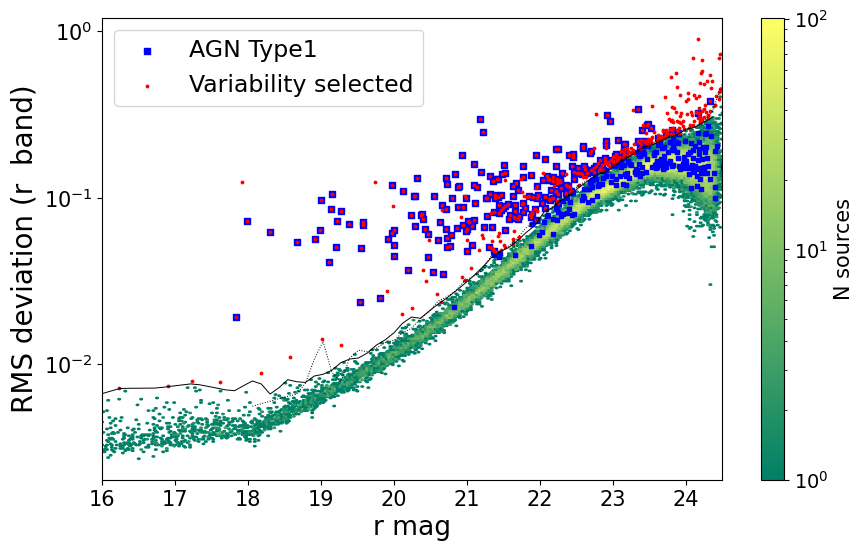

In [9]:
variable = df[f"std_selected_{band}"]
agn  = df["label"] ==3 

y = df[f"corrected_std_{band}"]
logy = np.log10(y)

mag = celib.flux_to_mag(df[f"{band}_psfFlux"])

fig, ax = plt.subplots(figsize = (10, 6))
hb = ax.hexbin(mag[~variable], logy[~variable], gridsize=300, cmap='summer', bins="log", mincnt=1)


ax.set_xlim(14, 25)
#ax.set_ylim(1e-4, 1.5)
cb = fig.colorbar(hb, ax=ax)
cb.set_label('N sources', fontsize = 15)

ax.scatter(mag[agn], logy[agn],s=8,  marker = "s", c="b")
ax.scatter(mag[agn & variable], logy[agn & variable],s=15,  marker = "s", c="b", label = "AGN Type1")

ax.scatter(mag[variable], logy[variable],s=3, c="red", label = "Variability selected")

ax.plot(xarray, np.log10(y_3sigma_extended), c = "k", lw= 0.7, ls = ':')
ax.plot(xarray, np.log10(y_3sigma_point), c = "k", lw = 0.7, ls ="-")
#ax.plot(xarray, np.log10(y_0sigma_extended), c = "k", lw= 0.7, ls = ':')
#ax.plot(xarray, np.log10(y_0sigma_point), c = "k", lw = 0.7, ls ="-")

ax.set_xlim(16, 24.5)
ax.set_yticks([-2,-1,0])  
ax.set_yticklabels([r"$10^{-2}$", r"$10^{-1}$", r"$10^{0}$"])
ax.set_xlabel(f"{band} mag", fontsize =19)
ax.set_ylabel(f"RMS deviation ({band}  band)", fontsize =20)
ax.tick_params(axis='both', which='major', labelsize=15)
cb.ax.tick_params(labelsize=14)
ax.legend(fontsize=17)
plt.savefig("../plot/rms_vs_mag_final.pdf", bbox_inches = "tight", dpi = 600)

In [10]:
df["agn_fraction_r"] = df["lsst-r_point"]/df["lsst-r_total"]
df.loc[df["label"] <3,  "agn_fraction_r"] = np.nan

In [11]:
df[f"std_selected_{band}_old"] = is_above_old

In [28]:
data =df.copy()
data = df[extended]
#data = df[~extended]


mag_cuts = [16, 29]
completeness, precision, N, _ = utility.get_completeness_precision_curve(data, parameter_name =  band, bins = mag_cuts,
                                                     selected_name = f"std_selected_{band}")

print(completeness)
print(1-precision)
print(N, completeness*N)

print("###################")

mag_cuts = [16, 21, 22, 28]
completeness, precision, N, _ = utility.get_completeness_precision_curve(data, parameter_name = band, bins = mag_cuts,
                                                     selected_name = f"std_selected_{band}")

print(completeness)
print(1-precision)
print(N, completeness*N)
print("###################")

mag_cuts = [16, 22.5, 24, 29]
completeness, precision, N, _ = utility.get_completeness_precision_curve(data, parameter_name = band, bins = mag_cuts,
                                                     selected_name = f"std_selected_{band}")

print(completeness)
print(1-precision)
print(N, completeness*N)                 


[0.41342756]
[0.62857143]
[283] [117.]
###################
[0.95       0.85294118 0.30131004]
[0.45714286 0.48214286 0.69196429]
[ 20  34 229] [19. 29. 69.]
###################
[0.78787879 0.27205882 0.04166667]
[0.39534884 0.72180451 0.96226415]
[ 99 136  48] [78. 37.  2.]


In [13]:

mag = celib.flux_to_mag(df[f"{band}_psfFlux"])
std =  df[f"std_{band}"].to_numpy()
binned_mean, _, edges = utility.get_mean_std_bins(mag[extended], std[extended], mean_func = "median", 
                                       clipping_sigma = clipping_sigma, bins = extended_bins)
select = extended & (df["label"] == 3)
phot_sigma2_ext, intrins_sigma2_ext = utility.get_photometric_and_intrinsic_variability(mag[select], std[select],
                                                                        bins=extended_bins, edges=edges, 
                                                                        binned_mean =binned_mean, 
                                                                        interpolate = interpolate)
binned_mean, _, edges = utility.get_mean_std_bins(mag[~extended], std[~extended], mean_func = "median", 
                                       clipping_sigma = clipping_sigma, bins = bins)
select_point = (~extended) & df["label"] == 3
phot_sigma2_point, intrins_sigma2_point = utility.get_photometric_and_intrinsic_variability(mag[select_point], std[select_point],
                                                                        bins=bins, edges=edges, 
                                                                        binned_mean =binned_mean, 
                                                                        interpolate = interpolate)

In [14]:
agn_df = df[df["label"] == 3].copy()
agn_df.loc[select, "measured_var"] = intrins_sigma2_ext
agn_df.loc[select_point, "measured_var"] = intrins_sigma2_point

true_std = pd.read_csv("Std_from_true_lc.dat", sep =" ")
agn_df = agn_df.merge(true_std, on = "ID")


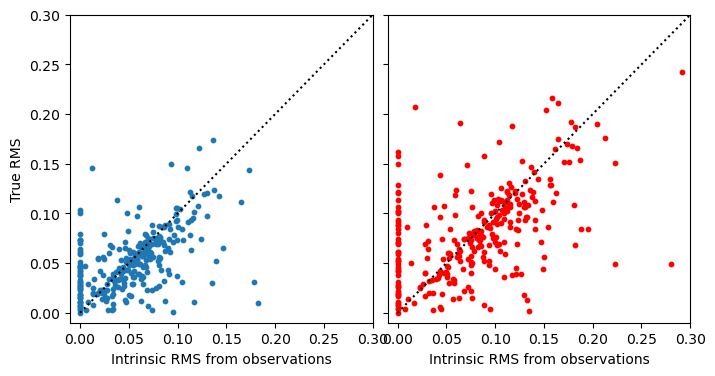

In [ ]:
fig, ax = plt.subplots(ncols =2, figsize = (8, 4), sharey = True, gridspec_kw = {"wspace" : 0.05})
ax[0].scatter(np.sqrt(agn_df["measured_var"]), (agn_df["true_std_non_corrected"]), s =10)
ax[1].scatter(np.sqrt(agn_df["measured_var"])*np.sqrt(agn_df["Z"]+1), (agn_df["true_std_non_corrected"]*np.sqrt(agn_df["Z"]+1)), c= "r", s =10)
ax[0].set_xlabel("Intrinsic RMS from observations")
ax[0].set_ylabel("True RMS")
ax[0].set_xlim(-0.01, 0.3)
ax[0].set_ylim(-0.01, 0.3)
ax[0].plot([0, 0.8], [0, 0.8], ls =":", c ="k")
ax[1].set_xlabel("Intrinsic RMS from observations")
ax[1].set_xlim(-0.01, 0.3)
ax[1].set_ylim(-0.01, 0.3)
ax[1].plot([0, 0.8], [0, 0.8], ls =":", c ="k")

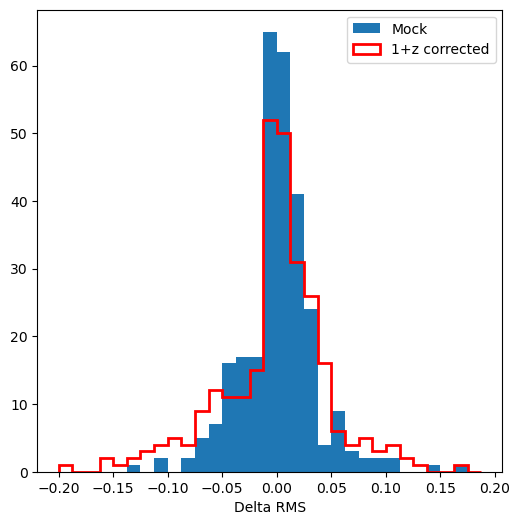

In [37]:
bins = np.arange(-0.2, 0.2, 0.0125)
fig, ax = plt.subplots(figsize = (6,6))
ax.hist(np.sqrt(agn_df["measured_var"])-(agn_df["true_std_non_corrected"]), bins = bins, label = "Mock");
ax.hist(np.sqrt(agn_df["measured_var"])*np.sqrt(agn_df["Z"]+1)-(agn_df["true_std_non_corrected"]*np.sqrt(agn_df["Z"]+1)), color= "r", bins = bins,
        histtype = "step", linewidth =2, label = "1+z corrected")
ax.set_xlabel("Delta RMS")
ax.legend()

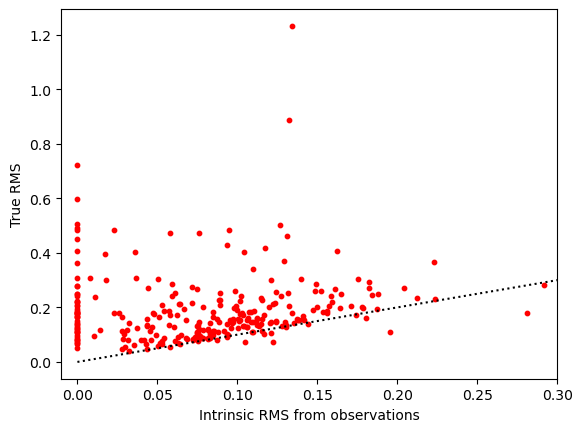

In [40]:
fig, ax = plt.subplots()
ax.scatter(np.sqrt(agn_df["measured_var"])*np.sqrt(agn_df["Z"]+1), (agn_df["true_std_non_corrected"]*np.sqrt(agn_df["Z"]+1)), c= "r", s =10)
ax.set_xlabel("Intrinsic RMS from observations")
ax.set_ylabel("True RMS")
ax.set_xlim(-0.01, 0.3)
ax.plot([0, 0.8], [0, 0.8], ls =":", c ="k")

In [ ]:
def update_sigma_df(table, band = "r",  clipping_sigma = 5,
                    bins = np.arange(14, 27, 0.33),
                    mean_func = "mean", interpolate = False):
    
    mag = celib.flux_to_mag(table[f"{band}_psfFlux"])
    std =  table[f"std_{band}"].to_numpy()

    binned_mean, _, edges = get_mean_std_bins(mag, std, mean_func = mean_func, 
                                       clipping_sigma = clipping_sigma, bins = bins)

    select = (table["label"] == 2) |  (table["label"] == 3) 

    phot_sigma2, intrins_sigma2 = get_photometric_and_intrinsic_variability(mag[select], std[select],
                                                                        bins=bins, edges=edges, 
                                                                        binned_mean =binned_mean, 
                                                                       interpolate = interpolate)
    new_sigma = np.sqrt(intrins_sigma2*(table.loc[select, "Z"]+1) + phot_sigma2)
    new_sigma = np.where(intrins_sigma2>0, new_sigma, std[select])
    new_df = table.copy()
    new_df.loc[select, f"std_{band}" ] = new_sigma
    return new_df

def get_photometric_and_intrinsic_variability(mag, std, bins, edges, binned_mean,
                              interpolate = False):
    if interpolate:
        xpos = 0.5*(edges[:-1]+edges[1:])
        f = interp1d(xpos, binned_mean, bounds_error=False, fill_value= np.nan)
        photometric_variability = f(mag)
    else:
        bin_idx = np.digitize(mag, bins=bins) - 1
        valid = (bin_idx >= 0) & (bin_idx < len(binned_mean))
        photometric_variability = np.full(len(mag), np.nan)
        photometric_variability[valid] = binned_mean[bin_idx[valid]]
    
    intrinsic_variability = np.maximum(std**2-photometric_variability**2, 0)
 
    return photometric_variability**2, intrinsic_variability

In [46]:
mag_cuts = [16, 22]
completeness, precision, N, _ = utility.get_completeness_precision_curve(df.loc[df["Z"]<0.7], parameter_name =  band, bins = mag_cuts,
                                                     selected_name = f"std_selected_{band}")

print(completeness)
print(1-precision)
print(N, completeness*N)

print("###################")

mag_cuts = [16, 22]
completeness, precision, N, _ = utility.get_completeness_precision_curve(df.loc[df["Z"]<0.7], parameter_name =  band, bins = mag_cuts,
                                                     selected_name = f"std_selected_{band}_old")

print(completeness)
print(1-precision)
print(N, completeness*N)


[0.76470588]
[0.61764706]
[17] [13.]
###################
[0.76470588]
[0.60606061]
[17] [13.]


In [28]:
(64 + 68)/(65+75)

0.9428571428571428

In [29]:
(63 + 57)/(65+75)

0.8571428571428571

In [ ]:
y = df[f"corrected_std_{band}"]
logy = np.log10(y)

mag = celib.flux_to_mag(df[f"{band}_psfFlux"])


fig, ax = plt.subplots(figsize = (10, 6))

/tmp/ipykernel_286398/495412557.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([r"$10^{-2}$", r"$10^{-1}$", r"$10^{0}$"])


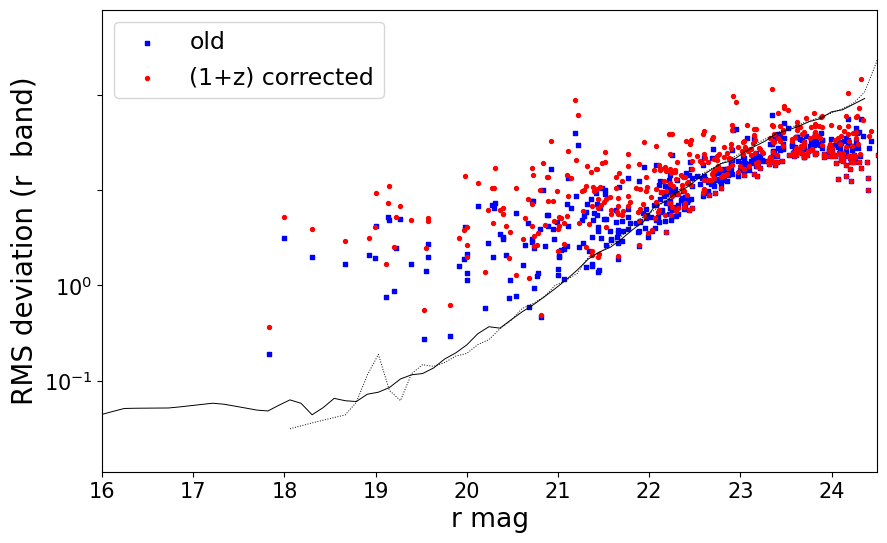

In [15]:
agn  = df["label"] ==3 
y_corr = df.loc[agn, f"corrected_std_{band}"]
logy_corr = np.log10(y_corr)

y_old = df.loc[agn, f"std_{band}"]
logy_old = np.log10(y_old)
mag = celib.flux_to_mag(df.loc[agn, [f"{band}_psfFlux"]])

fig, ax = plt.subplots(figsize = (10, 6))



ax.set_xlim(14, 25)

ax.scatter(mag, logy_old, s=8,  marker = "s", c="b", label = "old")
ax.scatter(mag, logy_corr,s=8,  marker = "o", c="r", label = "(1+z) corrected")


ax.plot(xarray, np.log10(y_3sigma_extended), c = "k", lw= 0.7, ls = ':')
ax.plot(xarray, np.log10(y_3sigma_point), c = "k", lw = 0.7, ls ="-")

ax.set_xlim(16, 24.5)
#ax.set_yticks([-2,-1,0])  
ax.set_yticklabels([r"$10^{-2}$", r"$10^{-1}$", r"$10^{0}$"])
ax.set_xlabel(f"{band} mag", fontsize =19)
ax.set_ylabel(f"RMS deviation ({band}  band)", fontsize =20)
ax.tick_params(axis='both', which='major', labelsize=15)
cb.ax.tick_params(labelsize=14)
ax.legend(fontsize=17)

Text(0.5, 0, 'Delta RMS')

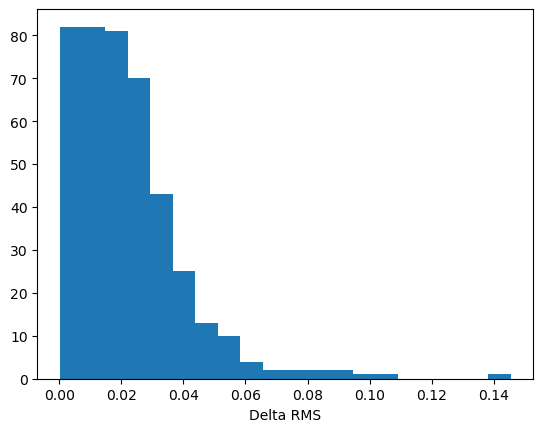

In [ ]:
fig, ax = plt.subplots()
ax.hist(y_corr-y_old, bins = 20)
ax.set_xlabel("Delta RMS")


In [38]:
x =np.ones(100)
y = 0.3*np.ones(100)
noise = np.random.rand(100)

In [41]:
print(np.std(np.log(x+y+noise)),np.std(np.log(0.5*x+y+noise)), np.std(np.log(noise)))

0.15299122330508722 0.21367707615815656 0.6917652324748851


In [10]:
cuts = [5, 6.3, 7.3, 8., 10]
completeness, precision, N, _ = utility.get_completeness_precision_curve(df, parameter_name = "MBH", bins = cuts,
                                                     selected_name = f"std_selected_{band}")
print(completeness)
#print(1-precision)
print(N, completeness*N)

print("###################")


cuts = [-3,-1, 0, 1, 3]
completeness, precision, N, _ = utility.get_completeness_precision_curve(df, parameter_name = "log_lambda_Edd", bins = cuts,
                                                     selected_name = f"std_selected_{band}")
print(completeness)
#print(1-precision)
print(N, completeness*N)

print("###################")

cuts = [0, 0.25, 0.5, 0.75, 0.9, 0.95, 1]
completeness, precision, N, _ = utility.get_completeness_precision_curve(df, parameter_name = "agn_fraction_r", bins = cuts,
                                                     selected_name = f"std_selected_{band}")
print(completeness)
#print(1-precision)
print(N, completeness*N)


[0.16842105 0.33333333 0.54700855 0.56      ]
[ 95 147 117  50] [16. 49. 64. 28.]
###################
[0.33898305 0.37278107 0.39583333 0.36      ]
[ 59 169 144  50] [20. 63. 57. 18.]
###################
[0.01587302 0.30769231 0.32911392 0.36585366 0.54237288 0.6091954 ]
[63 52 79 82 59 87] [ 1. 16. 26. 30. 32. 53.]


In [12]:
def get_completeness(selected):
    return np.sum(selected)/len(selected)


In [11]:
agn_df = df[df["label"]==3]

mag = celib.flux_to_mag(agn_df[f"{band}_psfFlux"])
mbh = agn_df["MBH"].to_numpy()
ledd = agn_df["log_lambda_Edd"]
agn_frac = agn_df["agn_fraction_r"].to_numpy()
selected = agn_df["std_selected_r"].to_numpy()


mass_bins = np.array([5, 7, 8, 10.001])
mag_bins = np.array([16, 21, 22, 25.5])
ledd_bins = [-3,-0.5, 0.5, 3]
frac_bins = np.array([0, 0.33, 0.66, 1.001])



In [22]:
values_mag_mbh, mag_edges, mbh_edges, _ = binned_statistic_2d(mag, mbh, selected, statistic = get_completeness,
                                             bins = (mag_bins, mass_bins))
counts_mag_mbh, _, _, _ = binned_statistic_2d(mag, mbh, selected, statistic = "count",
                                             bins = (mag_bins, mass_bins))


values_mag_edd, mag_edges, edd_edges, _ = binned_statistic_2d(mag, ledd, selected, statistic = get_completeness,
                                             bins = (mag_bins, ledd_bins))
counts_mag_edd, _,_, _ = binned_statistic_2d(mag, ledd, selected, statistic = "count",
                                             bins = (mag_bins, ledd_bins))


values_mbh_edd, mbh_edges, edd_edges, _ = binned_statistic_2d(mbh, ledd, selected, statistic = get_completeness,
                                             bins = (mass_bins, ledd_bins))
counts_mbh_edd, _, _, _ = binned_statistic_2d(mbh, ledd, selected, statistic = "count",
                                             bins = (mass_bins, ledd_bins))

values_frac_mbh, frac_edges, mbh_edges, _ = binned_statistic_2d(agn_frac, mbh, selected, statistic = get_completeness,
                                             bins = (frac_bins, mass_bins))
counts_frac_mbh, _, _, _ = binned_statistic_2d(agn_frac, mbh, selected, statistic = "count",
                                             bins = (frac_bins, mass_bins))


values_frac_edd, frac_edges, edd_edges, _ = binned_statistic_2d(agn_frac, ledd, selected, statistic = get_completeness,
                                            bins = (frac_bins, ledd_bins))
counts_frac_edd, _, _, _ = binned_statistic_2d(agn_frac, ledd, selected, statistic = "count",
                                             bins = (frac_bins, ledd_bins))



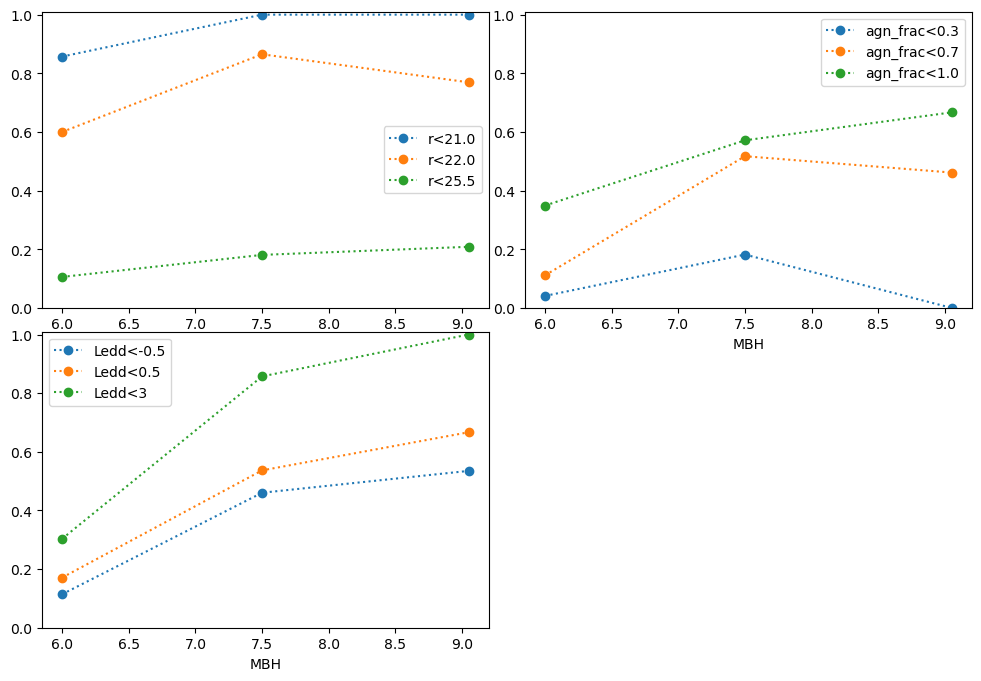

In [39]:
mbh_pos = 0.5*(mbh_edges[1:]+mbh_edges[:-1])
fig, axs = plt.subplots(nrows = 2, ncols = 2, figsize = (12,8), gridspec_kw={"wspace":0.08, "hspace":0.08})
for i, value in enumerate(mag_bins[1:]):
    axs[0,0].plot(mbh_pos, values_mag_mbh[i,:], marker ="o", ls = ":", label = f"r<{value}")
for i, value in enumerate(frac_bins[1:]):
    axs[0,1].plot(mbh_pos, values_frac_mbh[i,:], marker ="o", ls = ":", label = f"agn_frac<{np.round(value,1)}")
for i, value in enumerate(ledd_bins[1:]):
    axs[1,0].plot(mbh_pos, values_mbh_edd[:,i], marker ="o", ls = ":", label = f"Ledd<{np.round(value,1)}")

axs[0,0].set_xlabel("MBH")
axs[0,1].set_xlabel("MBH")
axs[1,0].set_xlabel("MBH")

axs[0,0].set_ylim(0,1.01)
axs[0,1].set_ylim(0,1.01)
axs[1,0].set_ylim(0,1.01)

axs[0,0].legend()
axs[0,1].legend()
axs[1,0].legend()
axs[1,1].remove()

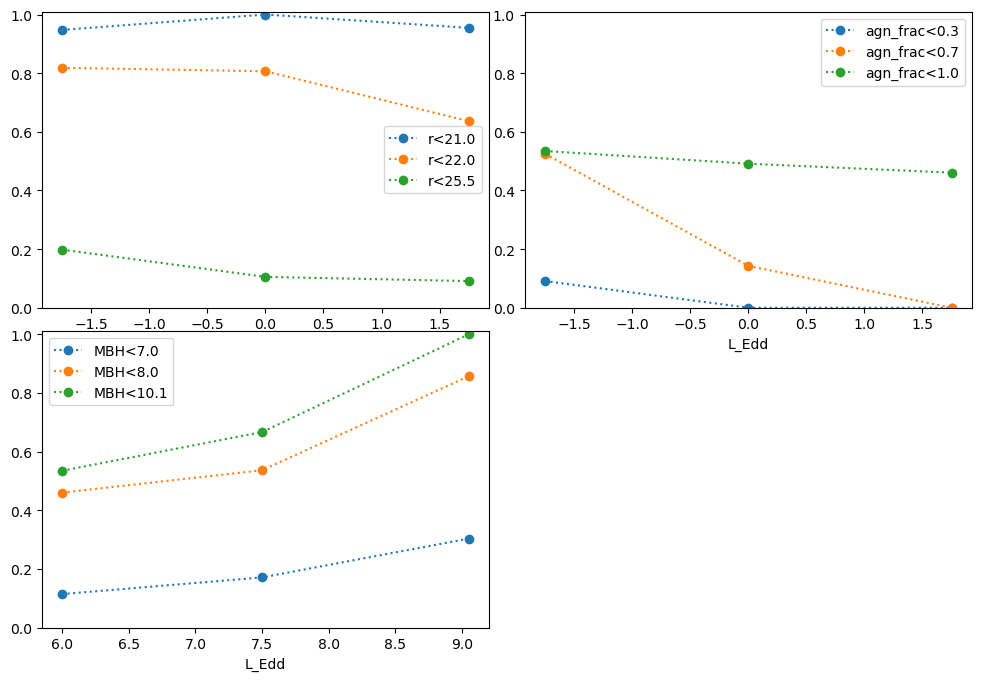

In [40]:
ledd_pos = 0.5*(edd_edges[1:]+edd_edges[:-1])
fig, axs = plt.subplots(nrows = 2, ncols = 2, figsize = (12,8), gridspec_kw={"wspace":0.08, "hspace":0.08})
for i, value in enumerate(mag_bins[1:]):
    axs[0,0].plot(ledd_pos, values_mag_edd[i,:], marker ="o", ls = ":", label = f"r<{value}")
for i, value in enumerate(frac_bins[1:]):
    axs[0,1].plot(ledd_pos, values_frac_edd[i,:], marker ="o", ls = ":", label = f"agn_frac<{np.round(value,1)}")
for i, value in enumerate(mass_bins[1:]):
    axs[1,0].plot(mbh_pos, values_mbh_edd[i,:], marker ="o", ls = ":", label = f"MBH<{np.round(value,1)}")

axs[0,0].set_xlabel("L_Edd")
axs[0,1].set_xlabel("L_Edd")
axs[1,0].set_xlabel("L_Edd")

axs[0,0].set_ylim(0,1.01)
axs[0,1].set_ylim(0,1.01)
axs[1,0].set_ylim(0,1.01)

axs[0,0].legend()
axs[0,1].legend()
axs[1,0].legend()
axs[1,1].remove()

In [46]:
print(values[2,:])
print(counts[2,:])


[0.53488372 0.66666667 1.        ]
[43.  6.  1.]


In [88]:
X, Y = np.meshgrid(xedges, yedges)
xpos = 0.5*(xedges[0:-1]+xedges[1:])
ypos = 0.5*(yedges[0:-1]+yedges[1:])

(5.5, 9.5)

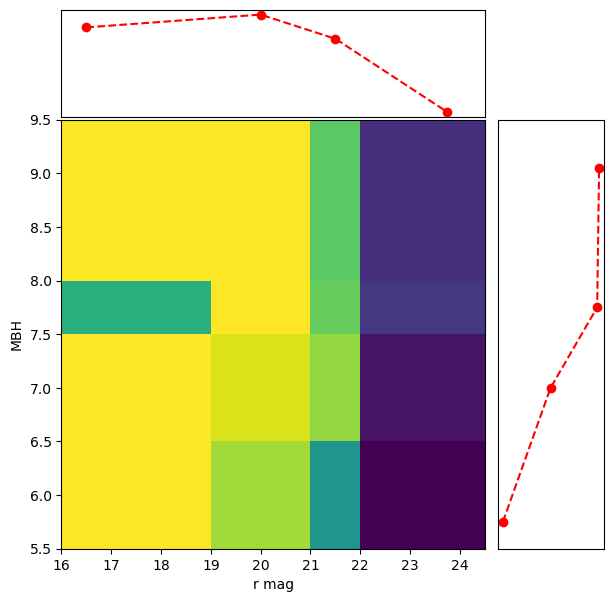

In [91]:
fig = plt.figure(figsize=(7,7))
gs = fig.add_gridspec(2, 2, width_ratios=(4,1), height_ratios=(1,4),
                      wspace=0.05, hspace=0.01)

ax = fig.add_subplot(gs[1,0])        # main plot
ax_xhist = fig.add_subplot(gs[0,0], sharex=ax)  # top marginal
ax_yhist = fig.add_subplot(gs[1,1], sharey=ax) 

pcm = ax.pcolormesh(X,Y, values.T)

ax_xhist.plot(xpos, values_mag, c="r", ls ="--", marker ="o")

ax_yhist.plot(values_mbh, ypos, c="r", ls ="--", marker ="o")

ax_yhist.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
ax_yhist.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)
ax_xhist.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
ax_xhist.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)
ax.set_xlabel("r mag")
ax.set_ylabel("MBH")
ax.set_xlim(16, 24.5)
ax.set_ylim(5.5, 9.5)

#cb = fig.colorbar(pcm, ax=ax)


In [76]:
values_mbh

array([0.19708029, 0.38095238, 0.55294118, 0.56      ])

(array([ 5., 18., 12.,  6., 15.,  9.,  4.,  8., 20., 13.,  8., 12., 13.,
        18., 20., 17., 21., 31., 34., 64., 74.]),
 array([-0.04,  0.01,  0.06,  0.11,  0.16,  0.21,  0.26,  0.31,  0.36,
         0.41,  0.46,  0.51,  0.56,  0.61,  0.66,  0.71,  0.76,  0.81,
         0.86,  0.91,  0.96,  1.01]),
 <BarContainer object of 21 artists>)

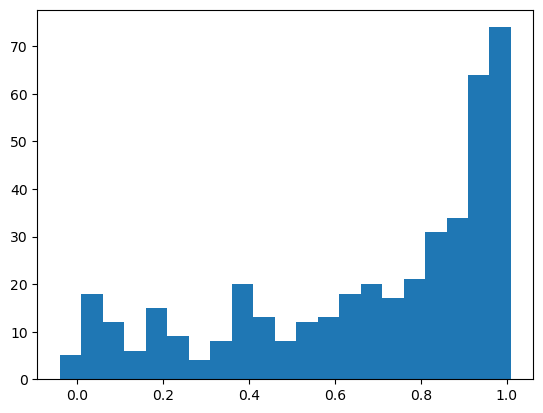

In [27]:
bins = np.arange(-0.04, 1.05, 0.05)
plt.hist(df["agn_fraction_r"], bins = bins)

/tmp/ipykernel_1321119/2566117253.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=17)


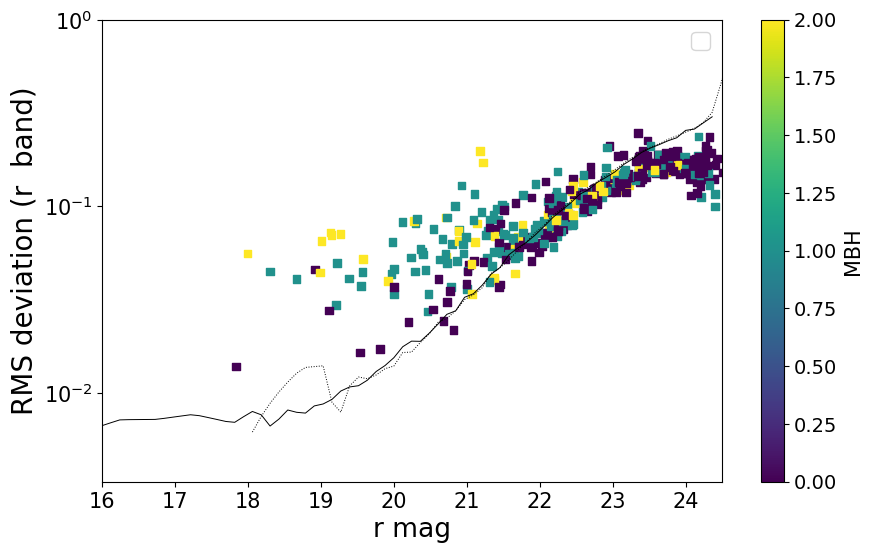

In [35]:
bins = [3, 7, 8, 11]  # log(MBH) ranges
labels = [0, 1, 2]    # integer labels for colors
df["MBH_bin"] = pd.cut(df["MBH"], bins=bins, labels=labels)

# Choose discrete colors
colors = ["blue", "green",  "red"]


agn  = df["label"] ==3 
y = df[f"std_{band}"]
logy = np.log10(y)


fig, ax = plt.subplots(figsize = (10, 6))

ax.set_xlim(14, 25)
#ax.set_ylim(1e-4, 1.5)

hb=ax.scatter(mag[agn], logy[agn],s=30,  marker = "s", c=df["MBH_bin"][agn].astype(int))

cb = fig.colorbar(hb, ax=ax)
cb.set_label('MBH', fontsize = 15)


ax.plot(xarray, np.log10(y_3sigma_extended), c = "k", lw= 0.7, ls = ':')
ax.plot(xarray, np.log10(y_3sigma_point), c = "k", lw = 0.7, ls ="-")

ax.set_xlim(16, 24.5)
ax.set_yticks([-2,-1,0])  
ax.set_yticklabels([r"$10^{-2}$", r"$10^{-1}$", r"$10^{0}$"])
ax.set_xlabel(f"{band} mag", fontsize =19)
ax.set_ylabel(f"RMS deviation ({band}  band)", fontsize =20)
ax.tick_params(axis='both', which='major', labelsize=15)
cb.ax.tick_params(labelsize=14)
ax.legend(fontsize=17)

In [34]:
df["MBH_bin"][agn]

1210        0
2113        2
2306        2
2755        0
5530        0
         ... 
288722    NaN
288939      0
290083      0
290209      1
290630      0
Name: MBH_bin, Length: 422, dtype: category
Categories (3, int64): [0 < 1 < 2]

Text(0, 0.5, 'Ledd')

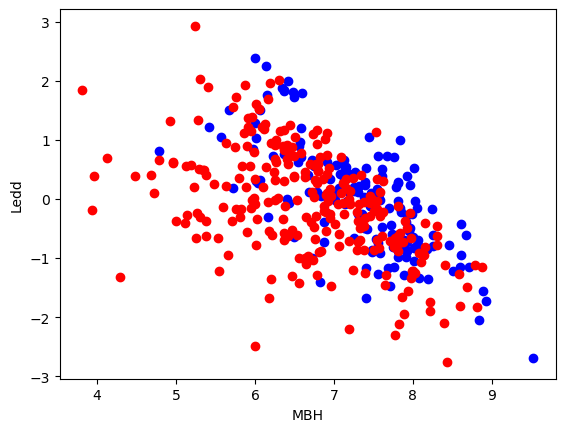

In [26]:
selected = df["std_selected_r"] ==1 
agn = df["label"] ==3 
fig, ax = plt.subplots()
ax.scatter(df.loc[agn & selected,"MBH"], df.loc[agn & selected,"log_lambda_Edd"], c ="b")
ax.scatter(df.loc[agn & (~selected),"MBH"], df.loc[agn & (~selected),"log_lambda_Edd"], c ="r")
ax.set_xlabel("MBH")
ax.set_ylabel("Ledd")

Text(0, 0.5, 'Lbol')

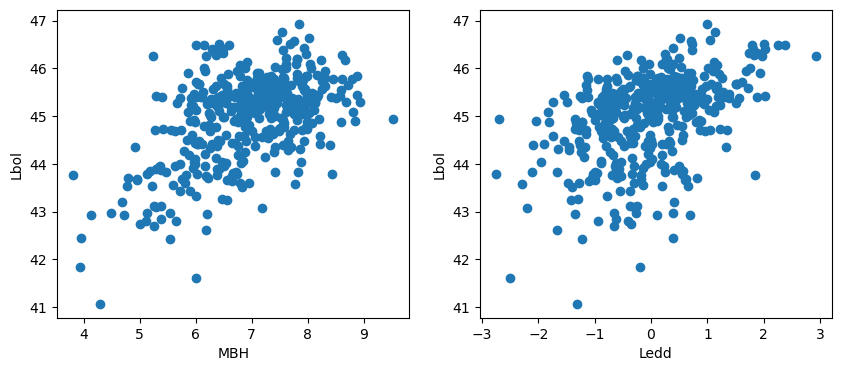

In [29]:
fig, ax = plt.subplots(ncols =2, figsize =(10,4))
ax[0].scatter(df.loc[agn, "MBH"], df.loc[agn, "log_L_bol"])
ax[1].scatter(df.loc[agn, "log_lambda_Edd"], df.loc[agn, "log_L_bol"])
ax[0].set_xlabel("MBH")
ax[1].set_xlabel("Ledd")
ax[0].set_ylabel("Lbol")
ax[1].set_ylabel("Lbol")

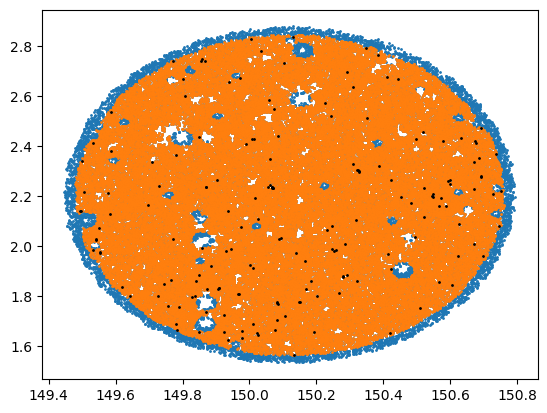

In [9]:
contaminants = df[f"std_selected_{band}"] & (df["label"]!=3)
fig, ax = plt.subplots()
ax.scatter(table["RA"], table["DEC"], s =1)
ax.scatter(df["RA"], df["DEC"],s =1)
ax.scatter(df["RA"][contaminants], df["DEC"][contaminants], c="k", s =1)


In [42]:
mag_cuts = np.array([16, 18, 20, 21, 21.5, 22,  22.5, 23, 23.5, 24, 28])
exteded = df[f"{band}_extendedness"]==1
e_completeness , e_precision, e_N, e_mag_mean = utility.get_completeness_precision_curve(df[extended], band = band, mag_cuts = mag_cuts,
                                                     selected_name = f"std_selected_{band}") 
p_completeness , p_precision, p_N, p_mag_mean = utility.get_completeness_precision_curve(df[~extended], band = band, mag_cuts = mag_cuts,
                                                     selected_name = f"std_selected_{band}") 
completeness ,precision, N, mag_mean = utility.get_completeness_precision_curve(df, band = band, mag_cuts = mag_cuts,
                                                     selected_name = f"std_selected_{band}") 

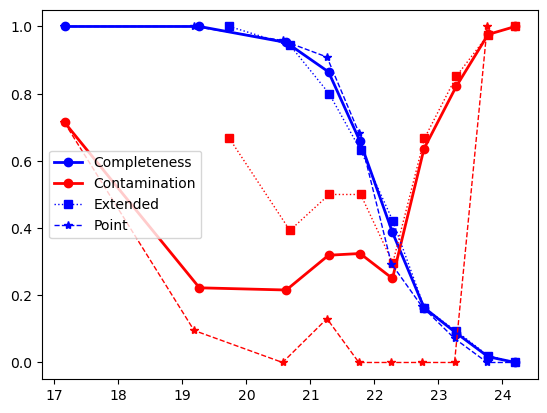

In [43]:
xpos = (mag_cuts[1:] + mag_cuts[:-1])*0.5
xpos[0] = 20.3
fig, ax = plt.subplots()
ax.plot(mag_mean, completeness, c = "b", lw =2, marker = "o", label = "Completeness")
ax.plot(mag_mean, 1-precision, c = "r", lw =2, marker = "o", label = "Contamination")
ax.plot(e_mag_mean, e_completeness, c = "b", lw =1, marker = "s", label = "Extended", ls = ":")
ax.plot(e_mag_mean, 1-e_precision, c = "r", lw =1, marker = "s", ls =":")
ax.plot(p_mag_mean, p_completeness, c = "b", lw =1, marker = "*", ls = "--", label = "Point")
ax.plot(p_mag_mean, 1-p_precision, c = "r", lw =1, marker = "*",  ls ="--")
ax.legend()

In [48]:
#Extended
mag_cuts = [16, 21, 22, 22.5, 23.,  28]
completeness, precision, N, _ = utility.get_completeness_precision_curve(df[extended], band = band, mag_cuts = mag_cuts,
                                                     selected_name = f"std_selected_{band}", target_label = 3)

print(completeness)
print(1-precision)
print(N, completeness*N)

mag_cuts = [16, 22.5]
completeness, precision, N, _ = utility.get_completeness_precision_curve(df[extended], band = band, mag_cuts = mag_cuts,
                                                     selected_name = f"std_selected_{band}", target_label =3)

print(completeness)
print(1-precision)
print(N, completeness*N)    

[0.95       0.70588235 0.42222222 0.1627907  0.03546099]
[0.44117647 0.5        0.2962963  0.66666667 0.95327103]
[ 20  34  45  43 141] [19. 24. 19.  7.  5.]
[0.62626263]
[0.43119266]
[99] [62.]


In [51]:
#Point like
mag_cuts = [16, 21, 22, 22.5, 23.,  28]
completeness, precision, N, _ = utility.get_completeness_precision_curve(df[~extended], band = band, mag_cuts = mag_cuts,
                                                     selected_name = f"std_selected_{band}", target_label = 3)

print(completeness)
print(1-precision)
print(N, completeness*N)

mag_cuts = [18, 23.5]
completeness, precision, N, _ = utility.get_completeness_precision_curve(df[~extended], band = band, mag_cuts = mag_cuts,
                                                     selected_name = f"std_selected_{band}", target_label =3)

print(completeness)
print(1-precision)
print(N, completeness*N)    

[0.97777778 0.80487805 0.29411765 0.16666667 0.03448276]
[0.1372549  0.08333333 0.         0.         0.5       ]
[45 41 17  6 29] [44. 33.  5.  1.  1.]
[0.67768595]
[0.05747126]
[121] [82.]


In [52]:

mag_cuts = [16, 21, 22, 28]
completeness, precision, N, _ = utility.get_completeness_precision_curve(df, band = band, mag_cuts = mag_cuts,
                                                     selected_name = f"std_selected_{band}", target_label = 2)

print(completeness)
print(1-precision)
print(N, completeness*N)

mag_cuts = [16, 28]
completeness, precision, N, _ = utility.get_completeness_precision_curve(df, band = band, mag_cuts = mag_cuts,
                                                     selected_name = f"std_selected_{band}", target_label =2)

print(completeness)
print(1-precision)
print(N, completeness*N)           

[0.08       0.         0.00118694]
[0.97647059 1.         0.98773006]
[  25  105 1685] [2. 0. 2.]
[0.00220386]
[0.98795181]
[1815] [4.]


In [ ]:
#Pointlike
mag_cuts = [16, 21, 22, 28]
completeness, precision, N, _ = utility.get_completeness_precision_curve(df, band = band, mag_cuts = mag_cuts,
                                                     selected_name = f"std_selected_{band}", target_label = 1)

print(completeness)
print(1-precision)
print(N, completeness*N)

mag_cuts = [16, 24]
completeness, precision, N, _ = utility.get_completeness_precision_curve(df, band = band, mag_cuts = mag_cuts,
                                                     selected_name = f"std_selected_{band}", target_label =1)

print(completeness)
print(1-precision)
print(N, completeness*N)

In [15]:
mag_cuts = np.array([16, 18, 20, 21, 21.5, 22,  22.5, 23, 23.5, 24, 28])
exteded = df[f"{band}_extendedness"]==1
e_tp , e_fp, e_Np, e_Nn = utility.get_metrics_numbers(df[extended], band = band, mag_cuts = mag_cuts,
                                                     selected_name = f"std_selected_{band}") 
p_tp , p_fp, p_Np, p_Nn = utility.get_metrics_numbers(df[~extended], band = band, mag_cuts = mag_cuts,
                                                     selected_name = f"std_selected_{band}") 
tp , fp, Np, Nn = utility.get_metrics_numbers(df, band = band, mag_cuts = mag_cuts,
                                                     selected_name = f"std_selected_{band}") 

In [16]:
minor = r"$\leq$"
xvariable = [f"{mag1} <= r < {mag2}" for mag1, mag2 in zip(mag_cuts[:-1],mag_cuts[1:])]

In [17]:
save_df = pd.DataFrame()
save_df["mag bin"] = xvariable
save_df["TP All"] = tp
save_df["FP All"] = fp
save_df["NP All"] = Np
save_df["NN All"] = Nn
save_df["TP Ext"] = e_tp
save_df["FP Ext"] = e_fp
save_df["NP Ext"] = e_Np
save_df["NN Ext"] = e_Nn
save_df["TP Point"] = p_tp
save_df["FP Point"] = p_fp
save_df["NP Point"] = p_Np
save_df["NN Point"] = p_Nn


In [61]:
def query_lightcurve(objectid, snr=5, band=None, max_rows=None,
                     difference_flux = False, npsfstar = 0):
    if not difference_flux:
        query = f"""
        SELECT f.objectId, f.band, ccd.expMidptMJD, f.psfFlux, f.psfFluxErr, ccd.nPsfStar
        FROM ForcedSource AS f
        LEFT JOIN (
                SELECT DISTINCT ccdVisitId, expMidptMJD, nPsfStar
                FROM CcdVisit) AS ccd USING (ccdVisitId)
        WHERE (f.psfFlux >= ? * f.psfFluxErr) AND f.psfFlux > 0
        AND f.detect_isPrimary = 1 
        AND f.objectId = ?
        AND ccd.nPsfStar >= ?
        """
        params = [snr, int(objectid), npsfstar]
    else:
        query = """
        SELECT f.objectId, f.band, ccd.expMidptMJD, f.psfDiffFlux AS psfFlux, 
        f.psfDiffFluxErr AS psfFluxErr, ccd.nPsfStar
        FROM ForcedSource AS f
        LEFT JOIN (
                SELECT DISTINCT ccdVisitId, expMidptMJD, nPsfStar
                FROM CcdVisit) AS ccd USING (ccdVisitId)
        WHERE f.psfDiffFlux IS NOT NULL AND f.psfDiffFluxErr IS NOT NULL 
        AND f.detect_isPrimary = 1 
        AND f.objectId = ?
        AND ccd.nPsfStar >= ?
        """
        params = [int(objectid), npsfstar]

    if band is not None:
        if isinstance(band, (list, tuple)):
            placeholders = ",".join("?" for _ in band)
            query += f" AND f.band IN ({placeholders})"
            params.extend(band)
        else:
            query += " AND f.band = ?"
            params.append(band)

    if max_rows is not None:
        query += " LIMIT ?"
        params.append(max(1, int(max_rows)))

    table = qlib.query_agile(query, params=params)  
    return table


In [62]:
def query_object(objectid, band= "r"):
    query = f"""SELECT objectId, {band}_psfFlux, {band}_psfFluxErr
                FROM Object
                WHERE objectId = {int(objectid)}
                """
    return qlib.query_agile(query)

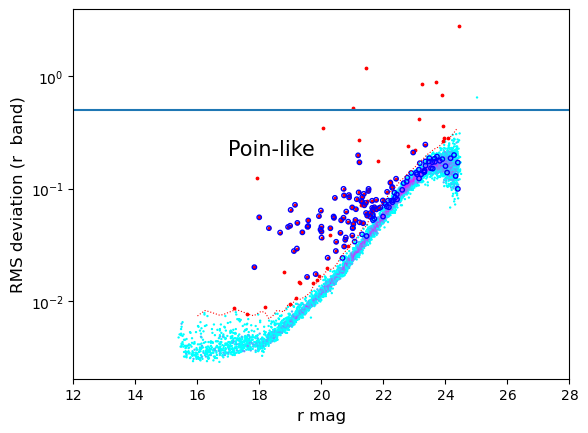

In [63]:

variable = df[f"std_selected_{band}"]
agn  = df["label"] ==3 

y = df[f"std_{band}"]
logy = np.log10(y)

fig, ax = plt.subplots()
hb = ax.hexbin(mag[~variable & ~extended], logy[~variable & ~extended], gridsize=300, cmap='cool', bins="log", mincnt=1)
ax.set_xlim(12, 28)
ax.scatter(mag[variable & ~extended], logy[variable & ~extended],s=3, c="red")
ax.scatter(mag[agn & ~extended], logy[agn & ~extended],s=10, marker = "o", edgecolor="blue", facecolor = "none")
ax.plot(xarray, np.log10(y_3sigma_point), ls = ":", lw = 0.8, c ="r")
ax.set_yticks([-2,-1,0])  
ax.set_yticklabels([r"$10^{-2}$", r"$10^{-1}$", r"$10^{0}$"])
ax.set_xlabel(f"{band} mag", fontsize =12)
ax.set_ylabel(f"RMS deviation ({band}  band)", fontsize = 12)
ax.text(17, -0.7, "Poin-like", fontsize = 15)
ax.axhline(np.log10(0.5))

In [64]:
strani = df[np.logical_and(df["std_r"]> 0.5, ~extended)]

In [65]:
strani[["objectId", "n_epochs_r","std_r"]]

,objectId,n_epochs_r,std_r
60390,4229636514100818856,46.0,0.646826
90756,4229662902379887231,81.0,1.170526
90819,4229662902379887327,22.0,0.683842
197775,4229768455496161513,152.0,0.851807
204076,4229777251589178772,10.0,2.792852
263616,4229882804705431974,72.0,0.516729
277651,4229530960984544777,30.0,0.879821


In [66]:
from numba import njit

In [103]:
@njit
def sigma_clip(mag, magerr, num_sigma=5):
    """Clip light curve based on deviations from median"""
    med = np.median(mag)
    sigma = 0.6745 * np.median(np.abs(mag - med))
    res = mag - med
    return np.abs(res - magerr) < num_sigma*sigma

In [104]:
objectid = 4229768455496161513

table_all  = query_lightcurve(objectid, band ="r", difference_flux = True)
table_psf = query_lightcurve(objectid, band ="r", npsfstar=30, difference_flux = True)
flux =query_object(objectid)

flux_all = table_all["psfFlux"].to_numpy() + flux["r_psfFlux"].iloc[0]
fluxerr_all = table_all["psfFluxErr"].to_numpy() + flux["r_psfFluxErr"].iloc[0]

flux_psf = table_psf["psfFlux"].to_numpy() + flux["r_psfFlux"].iloc[0]
fluxerr_psf = table_psf["psfFluxErr"].to_numpy() + flux["r_psfFluxErr"].iloc[0]



select = flux_psf>= 5* fluxerr_psf
flux_psf, fluxerr_psf = flux_psf[select], fluxerr_psf[select]
table_psf = table_psf[select]

select = flux_all>= 5* fluxerr_all
flux_all, fluxerr_all = flux_all[select], fluxerr_all[select]
table_all = table_all[select]

In [105]:
mag, err = celib.flux_to_mag(flux_all), celib.err_flux_to_err_mag(fluxerr_all, flux_all)
idx = sigma_clip(mag, err)

In [106]:
err

array([0.1792482 , 0.2119595 , 0.15238023, 0.20544907, 0.18035316,
       0.16603832, 0.19789865, 0.12619761, 0.17139631, 0.21675214,
       0.13909642, 0.11850137, 0.12995892, 0.14889888, 0.1695015 ,
       0.14003466, 0.11321619, 0.12403505, 0.1236015 , 0.12555063,
       0.13158781, 0.14149588, 0.14701092, 0.12222097, 0.13228624,
       0.13775207, 0.12966756, 0.15043559, 0.14731861, 0.12392903,
       0.11342834, 0.11597579, 0.17376731, 0.12630132, 0.13086599,
       0.1579704 , 0.09109177, 0.10193296, 0.17188381, 0.17109017,
       0.14013661, 0.12137604, 0.17211724, 0.20904614, 0.20020333,
       0.03966481, 0.1274026 , 0.12577968, 0.12345958, 0.09652283,
       0.12422   , 0.112213  , 0.11275195, 0.10470572, 0.10263594,
       0.12321172, 0.11679953, 0.10745007, 0.09808034, 0.12472899,
       0.12331683, 0.10607772, 0.15002837, 0.12857893, 0.13907114,
       0.12345406, 0.10293375, 0.17856663, 0.14375125, 0.12354521,
       0.09057793, 0.1188866 , 0.1614936 , 0.09948107, 0.20753

In [97]:
med = np.median(mag)
sigma = 0.6745 * np.median(np.abs(mag - med))
res = mag - med

In [100]:
res

array([-4.33432186e-02,  1.02005278e-02, -1.19460021e-01, -1.46621383e-01,
        2.37900447e-02, -1.52587496e-01,  2.48863191e-02, -2.44900826e-01,
       -1.59005768e-01, -1.20730761e-01,  2.16311367e-01, -3.20112616e-01,
        2.01668036e-02,  2.41598534e-02, -2.78202422e-01, -1.93857563e-01,
        7.39388295e-02,  9.56041067e-02,  1.50366255e-01,  1.13405792e-01,
       -4.40976588e-02,  5.61356962e-02, -1.07314273e-02, -6.79865461e-02,
        3.93970652e-02, -4.02095536e-02,  6.43038953e-02,  2.14609115e-02,
       -1.48278642e-01,  2.01885995e-02, -9.73449279e-02,  1.97928081e-02,
        1.83260043e-01, -8.68786594e-02,  8.18587803e-02,  8.12816223e-02,
       -1.13024043e-01,  6.17549903e-03,  1.33743835e-01, -4.47942064e-02,
       -1.41325520e-01, -1.64379644e-01, -1.19539589e-01, -1.41090126e-01,
        1.31746638e-01,  5.63139113e-02,  4.83700266e-02,  1.22231341e-01,
       -2.84918036e-02, -1.27940689e-01, -1.33187592e-01,  1.55347895e-01,
       -8.76319097e-02,  

In [102]:
np.abs(res - err) < 5*sigma

array([ True,  True,  True, False,  True, False,  True, False, False,
       False,  True, False,  True,  True, False, False,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True, False,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True, False,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True, False, False,  True, False,  True,  True,
        True,  True,  True, False,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True, False,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True, False,  True,  True,  True,
        True,  True,

<ErrorbarContainer object of 3 artists>

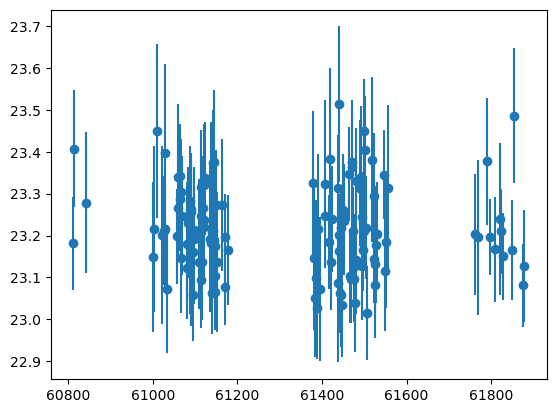

In [108]:
fig, ax = plt.subplots()
ax.errorbar(table_all["expMidptMJD"][idx], celib.flux_to_mag(flux_all[idx]),  celib.err_flux_to_err_mag(fluxerr_all[idx], flux_all[idx]), ls = "none", marker ="o")
#ax.scatter(table_psf["expMidptMJD"], celib.flux_to_mag(flux_psf))

In [48]:
np.std( celib.flux_to_mag(table_all["psfFlux"]))

0.5150544919939574

In [87]:
len(flux_psf)

151

In [17]:
path = "/data1/isaccheo/standard_features/2025-11-04/patch_19"

In [18]:
celib.read_metadata(path)

{'pandas': '{"index_columns": ["__index_level_0__"], "column_indexes": [{"name": "feature", "field_name": "feature", "pandas_type": "unicode", "numpy_type": "object", "metadata": {"encoding": "UTF-8"}}, {"name": null, "field_name": null, "pandas_type": "unicode", "numpy_type": "object", "metadata": {"encoding": "UTF-8"}}], "columns": [{"name": "(\'flux_percentile_ratio_mid20\', \'u\')", "field_name": "(\'flux_percentile_ratio_mid20\', \'u\')", "pandas_type": "float64", "numpy_type": "float64", "metadata": null}, {"name": "(\'flux_percentile_ratio_mid20\', \'g\')", "field_name": "(\'flux_percentile_ratio_mid20\', \'g\')", "pandas_type": "float64", "numpy_type": "float64", "metadata": null}, {"name": "(\'flux_percentile_ratio_mid20\', \'r\')", "field_name": "(\'flux_percentile_ratio_mid20\', \'r\')", "pandas_type": "float64", "numpy_type": "float64", "metadata": null}, {"name": "(\'flux_percentile_ratio_mid20\', \'i\')", "field_name": "(\'flux_percentile_ratio_mid20\', \'i\')", "pandas_t

In [ ]:
def get_completeness_precision_curve(df, parameter_name = "r", bins = np.arange(15, 28, 1),
                                     cumulative = False, target_label = 3,
                                     label_name = "label", selected_name = "std_selected"):
    
    if parameter_name in ("ugrizy"):
        values = celib.flux_to_mag(df[f"{parameter_name}_psfFlux"])
    else:
        values = df[parameter_name].to_numpy()
    completeness, precision, N, value_mean = [], [], [], []
    for bin_low, bin_high in zip(bins[:-1], bins[1:]):
        if cumulative:
            logic = values < bin_high
        else:
            logic = (values < bin_high) & (values>= bin_low)
        labels, selected = df[label_name][logic].to_numpy(), df[selected_name][logic].to_numpy()
        completeness.append(get_completeness(labels, selected, target_label = target_label))
        precision.append(get_precision(labels, selected, target_label = target_label))
        N.append(get_N_positives(labels, target_label = target_label))
        value_mean.append(np.nanmedian(values[logic]))

    return np.array(completeness), np.array(precision), np.array(N), np.array(value_mean)